In [ ]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

# ResNet

In [ ]:
!pip -q install lightning torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 52.6 MB/s eta 0:00:00


In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

## Model Define

In [ ]:
class BottleNeck(nn.Module):
    def __init__(self, in_channels, base_channels, stride=1, conv_shortcut=False):
        super().__init__()
        if conv_shortcut: # Conv Block
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, base_channels*4, 1, stride, bias=False),
                nn.BatchNorm2d(base_channels*4)
            )
        else : # Identity Block
            self.shortcut = nn.Sequential()

        self.residual_function = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 1, 1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(),
            nn.Conv2d(base_channels, base_channels, 3, stride, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(),
            nn.Conv2d(base_channels, base_channels * 4, 1, 1, bias=False),
            nn.BatchNorm2d(base_channels * 4),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.residual_function(x) + self.shortcut(x)
        x = self.relu(x)
        return x

In [ ]:
# nn.Conv2d(in_c, out_c, kernel_size, stride, padding, bias=True)
# nn.MaxPool2d(kernel_size, stride, padding)

class ResNet(nn.Module):
    def __init__(self, num_block, num_classes=1000):
        super().__init__()
        self.in_channels=64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3, bias=False),           #(64,112,112)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1) #(64,56,56)
        )
        ## Stacking Conv Block ##
        self.conv2_x = self._make_blocks(64, 64, num_block[0], 1)
        self.conv3_x = self._make_blocks(256, 128, num_block[1], 2)
        self.conv4_x = self._make_blocks(512, 256, num_block[2], 2)
        self.conv5_x = self._make_blocks(1024, 512, num_block[3], 2)
        ##
        self.avg_pool = nn.AdaptiveAvgPool2d((1,1))#out:(1,1)#(2048,1,1)
        self.fc = nn.Linear(512*4, num_classes)              #(1000)

    def _make_blocks(self, in_channels, base_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1) #[1,1,1] or [2,1,1]
        layers = []
        layers.append(BottleNeck(in_channels, base_channels, strides[0],
                                                                   conv_shortcut=True))
        for n_block in range(1, num_blocks):
            layers.append(BottleNeck(base_channels*4, base_channels, strides[n_block]))
        return nn.Sequential(*layers)

    def forward(self,x):
        x = self.conv1(x)
        x = self.conv2_x(x)
        x = self.conv3_x(x)
        x = self.conv4_x(x)
        x = self.conv5_x(x)
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1) ## flatten
        x = self.fc(x)
        return x

In [ ]:
class ResNet_pl(L.LightningModule):
    def __init__(self, num_block, num_classes=1000):
        super().__init__()
        self.net = ResNet(num_block, num_classes)

    def forward(self,x):
        x = self.net(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=5)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=5)
        metrics = {'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

In [ ]:
def resnet50():
    return ResNet_pl([3, 4, 6, 3])

def resnet152():
    return ResNet_pl([3, 8, 36, 3])

In [ ]:
model = resnet50()
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet_pl                                     [1, 1000]                 --
├─ResNet: 1-1                                 [1, 1000]                 --
│    └─Sequential: 2-1                        [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                       [1, 64, 112, 112]         9,408
│    │    └─BatchNorm2d: 3-2                  [1, 64, 112, 112]         128
│    │    └─ReLU: 3-3                         [1, 64, 112, 112]         --
│    │    └─MaxPool2d: 3-4                    [1, 64, 56, 56]           --
│    └─Sequential: 2-2                        [1, 256, 56, 56]          --
│    │    └─BottleNeck: 3-5                   [1, 256, 56, 56]          75,008
│    │    └─BottleNeck: 3-6                   [1, 256, 56, 56]          70,400
│    │    └─BottleNeck: 3-7                   [1, 256, 56, 56]          70,400
│    └─Sequential: 2-3                        [1, 512, 28, 28]          --
│   

In [ ]:
model

ResNet_pl(
  (net): ResNet(
    (conv1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (conv2_x): Sequential(
      (0): BottleNeck(
        (shortcut): Sequential(
          (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (residual_function): Sequential(
          (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=T

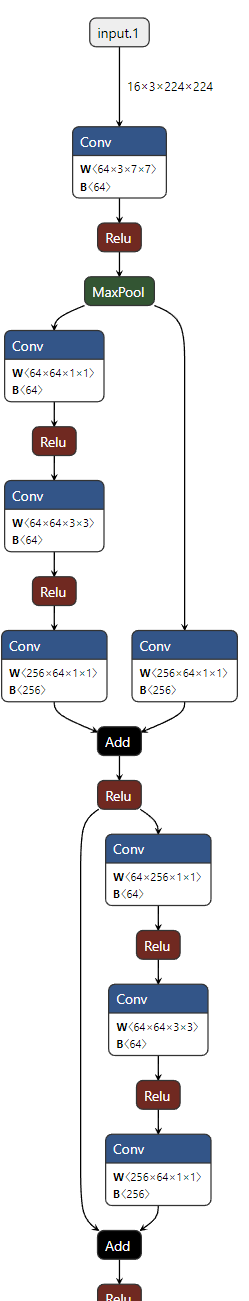

In [ ]:
#torch.onnx.export(model, torch.zeros(16, 3, 224, 224).to(device), 'resnet50.onnx')

In [ ]:
model2 = resnet152()
summary(model2, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet_pl                                     [1, 1000]                 --
├─ResNet: 1-1                                 [1, 1000]                 --
│    └─Sequential: 2-1                        [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                       [1, 64, 112, 112]         9,408
│    │    └─BatchNorm2d: 3-2                  [1, 64, 112, 112]         128
│    │    └─ReLU: 3-3                         [1, 64, 112, 112]         --
│    │    └─MaxPool2d: 3-4                    [1, 64, 56, 56]           --
│    └─Sequential: 2-2                        [1, 256, 56, 56]          --
│    │    └─BottleNeck: 3-5                   [1, 256, 56, 56]          75,008
│    │    └─BottleNeck: 3-6                   [1, 256, 56, 56]          70,400
│    │    └─BottleNeck: 3-7                   [1, 256, 56, 56]          70,400
│    └─Sequential: 2-3                        [1, 512, 28, 28]          --
│   

In [ ]:
#torch.onnx.export(model2, torch.zeros(16, 3, 224, 224).to(device), 'resnet152.onnx')

**Pre-Trained ResNet**
https://pytorch.org/vision/stable/models.html#classification

|Model | Acc@1 | Acc@5|
|---|---|---|
ResNet-18| 69.758|89.078
ResNet-34|73.314|91.420
ResNet-50|76.130|92.862
ResNet-101|77.374|93.546
ResNet-152|78.312|94.046

**Pre-Trained DenseNet**

|Model | Acc@1 | Acc@5|
|---|---|---|
Densenet-121|74.434|91.972
Densenet-169|75.600|92.806
Densenet-201|76.896|93.370
Densenet-161|77.138|93.560

# 실습과제 : Cumstom ResNet : ResNet26

#### **Flower Photos Dataset Load**  추가하세요.

### Model Define

In [ ]:
##
blocks = [2,2,2,2]
##

def resnet26():
    return ResNet_pl(blocks,num_classes=5)

In [ ]:
model = resnet26()
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet_pl                                     [1, 5]                    --
├─ResNet: 1-1                                 [1, 5]                    --
│    └─Sequential: 2-1                        [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                       [1, 64, 112, 112]         9,408
│    │    └─BatchNorm2d: 3-2                  [1, 64, 112, 112]         128
│    │    └─ReLU: 3-3                         [1, 64, 112, 112]         --
│    │    └─MaxPool2d: 3-4                    [1, 64, 56, 56]           --
│    └─Sequential: 2-2                        [1, 256, 56, 56]          --
│    │    └─BottleNeck: 3-5                   [1, 256, 56, 56]          75,008
│    │    └─BottleNeck: 3-6                   [1, 256, 56, 56]          70,400
│    └─Sequential: 2-3                        [1, 512, 28, 28]          --
│    │    └─BottleNeck: 3-7                   [1, 512, 28, 28]          379,392
│  

### Training

In [ ]:
%%time
model = resnet26()
model_name = "ResNet26"

epochs=20
logger = CSVLogger("logs", name=model_name)
trainer = Trainer(max_epochs=epochs, logger=logger,
                  limit_train_batches=1.0, limit_val_batches=1.0)
trainer.fit(model, train_loader, test_loader)

#### Plot

## lr-scheduler 적용

In [ ]:
epochs=20
lr_start = 0.001

In [ ]:
decay_steps = epochs//3.5
decay_rate=0.6
def exponential_decay_lambda(epoch):
    return decay_rate ** (epoch // decay_steps)

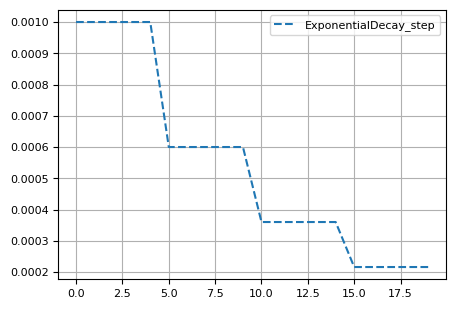

In [ ]:
exp_lr_s=[]

for step in range(epochs):
    exp_lr_s.append(exponential_decay_lambda(step)*lr_start)

plt.plot(exp_lr_s, linestyle='--', label="ExponentialDecay_step")
plt.legend()
plt.grid()

- define lr scheduling

In [ ]:
class ResNet_lr(ResNet_pl):
    def __init__(self, num_block, num_classes=5):
        super(ResNet_lr,self).__init__( num_block, num_classes)

    def configure_optimizers(self):
        optimizer =  torch.optim.Adam(self.parameters(), lr=lr_start)
        lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda = exponential_decay_lambda)
        return [optimizer], [lr_scheduler]